In [1]:
!pip install yfinance hmmlearn --quiet

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
import yfinance as yf
import pandas as pd

# Pull all 5 Kroniq core assets — correct tickers
# Note: VIX uses ^VIX on Yahoo Finance
tickers = ["SPY", "QQQ", "^VIX", "TLT", "GLD"]
data = yf.download(tickers, start="2015-01-01", end="2025-12-31")["Close"]

# Rename ^VIX column to VIX for clean column names
data = data.rename(columns={"^VIX": "VIX"})

# Reorder columns cleanly
data = data[["SPY", "QQQ", "VIX", "TLT", "GLD"]]

# Calculate daily returns — fill_method=None fixes the FutureWarning
returns = data.pct_change(fill_method=None).dropna()

# Save both to CSV
data.to_csv("kroniq_5asset_prices.csv")
returns.to_csv("kroniq_5asset_returns.csv")

# Confirm everything loaded correctly
print("Assets loaded:", data.columns.tolist())
print("Date range:", data.index[0], "to", data.index[-1])
print("Total rows:", len(data))
print("Missing values per column:")
print(data.isnull().sum())
print()
print(data.tail())

[*********************100%***********************]  5 of 5 completed


Assets loaded: ['SPY', 'QQQ', 'VIX', 'TLT', 'GLD']
Date range: 2015-01-02 00:00:00 to 2025-12-30 00:00:00
Total rows: 2765
Missing values per column:
Ticker
SPY    0
QQQ    0
VIX    0
TLT    0
GLD    0
dtype: int64

Ticker             SPY         QQQ    VIX        TLT         GLD
Date                                                            
2025-12-23  686.086304  622.109985  14.00  86.877693  413.640015
2025-12-24  688.499695  623.929993  13.47  87.403931  411.929993
2025-12-26  688.429871  623.890015  13.60  87.115982  416.739990
2025-12-29  685.976562  620.869995  14.20  87.443649  398.600006
2025-12-30  685.138916  619.429993  14.33  87.235130  398.890015


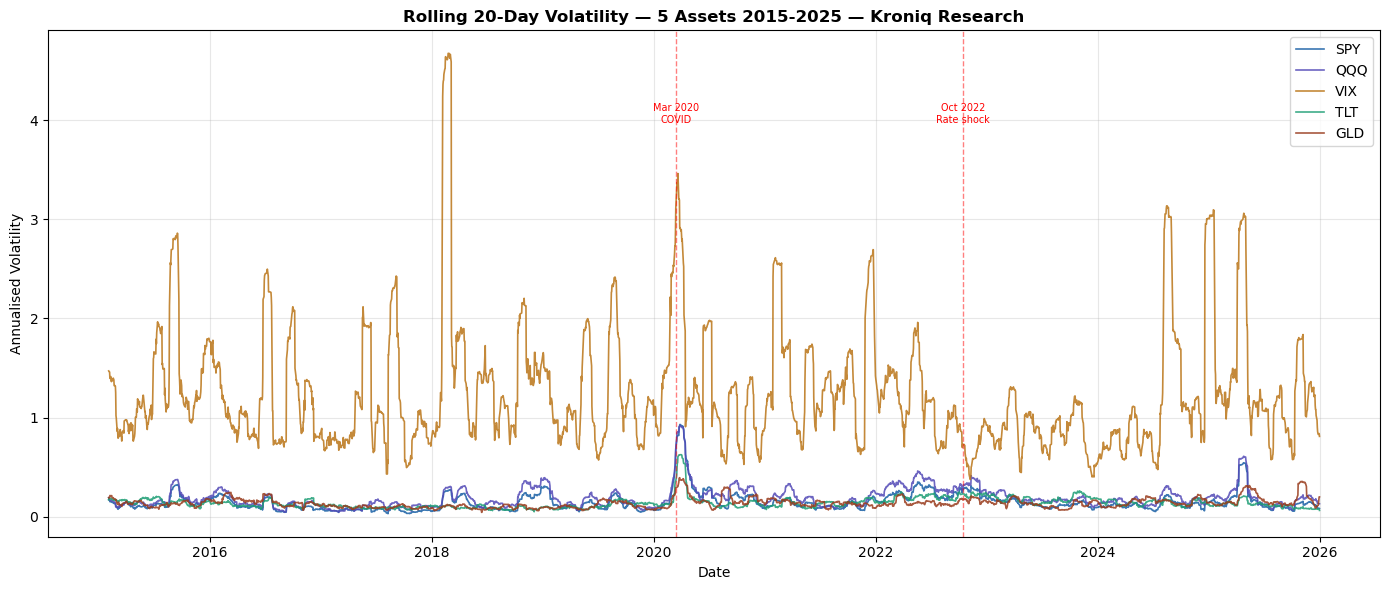

Chart saved.


In [5]:
import matplotlib.pyplot as plt

# Rolling 20-day volatility — annualised
rolling_vol = returns.rolling(window=20).std() * (252 ** 0.5)

# Plot all 5
fig, ax = plt.subplots(figsize=(14, 6))
colors = {
    "SPY": "#185FA5", "QQQ": "#534AB7",
    "VIX": "#BA7517", "TLT": "#1D9E75", "GLD": "#993C1D"
}
for col in rolling_vol.columns:
    ax.plot(rolling_vol.index, rolling_vol[col],
            label=col, color=colors.get(col, "gray"),
            linewidth=1.2, alpha=0.85)

# Mark key regime events
for label, date in [("Mar 2020\nCOVID", "2020-03-15"),
                     ("Oct 2022\nRate shock", "2022-10-15")]:
    ax.axvline(pd.Timestamp(date), color="red",
               linestyle="--", alpha=0.5, linewidth=1)
    ax.text(pd.Timestamp(date), rolling_vol.max().max() * 0.85,
            label, fontsize=7, color="red", ha="center")

ax.set_title("Rolling 20-Day Volatility — 5 Assets 2015-2025 — Kroniq Research",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Annualised Volatility")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("kroniq_5asset_volatility.png", dpi=150)
plt.show()
print("Chart saved.")